# Boltz-2 versus Nesso-1 on 50 post-cutoff complexes

This notebook is a presentation-oriented companion to `exp015`. It reads the
reviewed, machine-readable result; it is not the only record of the experiment.
The model commands, settings, failures, and raw outputs are preserved separately.


## 1. The question

We selected 50 diverse Runs N’ Poses protein-ligand complexes released after
1 June 2023. Both models received the same deposited protein sequence and
ligand SMILES. Boltz-2 also received a sequence-derived MSA. Neither model saw
the experimental coordinates until scoring.

This asks about **structure recovery**, not affinity prediction. Nesso-1 returns
protein-ligand distance distributions; Boltz-2 returns an explicit 3D complex.


In [1]:
from pathlib import Path
import json
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
import pandas as pd
from IPython.display import Image, display

def find_repo_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / "reports/exp015_boltz2_nesso1_rnp_postcutoff50/results/summary.json").exists():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the BindingAffinityPredictor repository")

ROOT = find_repo_root()
RESULT = ROOT / "reports/exp015_boltz2_nesso1_rnp_postcutoff50/results"
summary = json.loads((RESULT / "summary.json").read_text())
print(f"Loaded {summary['paired_systems']} paired systems from {RESULT.relative_to(ROOT)}")

Loaded 49 paired systems from reports/exp015_boltz2_nesso1_rnp_postcutoff50/results


## 2. Completion and local speed

In [2]:
completion = pd.DataFrame(summary["completion"]).T[["attempted", "completed", "failed"]]
runtime = summary["runtime"]
completion["seconds / attempted system"] = [
    runtime["nesso1_seconds_per_attempted_system"],
    runtime["boltz2_seconds_per_attempted_system"],
]
display(completion.round(2))
print(f"Boltz-2/Nesso-1 runtime ratio: {runtime['boltz2_to_nesso1_ratio_per_attempted_system']:.2f}×")
print("MSA-server time is excluded from the Boltz-2 number.")

,attempted,completed,failed,seconds / attempted system
nesso1,50.0,50.0,0.0,6.52
boltz2,50,49,1,23.63


Boltz-2/Nesso-1 runtime ratio: 3.62×
MSA-server time is excluded from the Boltz-2 number.


Boltz-2 produced 49 structures. The missing case, 8UK6, contains
818 protein residues and exceeded the 10 GiB GPU limit under the frozen
MSA-1024 protocol. Nesso-1 completed all 50. The paired accuracy comparison
therefore uses the 49 systems completed by both models.

## 3. Paired structural accuracy

In [3]:
labels = {
    "interface_expected_distance_mae_angstrom": "Interface distance MAE (Å; lower better)",
    "token_contact_f1_at_6a": "6 Å token-contact F1 (higher better)",
    "physical_pocket_f1_at_6a": "6 Å pocket F1 (higher better)",
}
rows = []
for metric, label in labels.items():
    result = summary["paired_metrics"][metric]
    rows.append({
        "metric": label,
        "Nesso-1 median": result["nesso1_median"],
        "Boltz-2 median": result["boltz2_median"],
        "Boltz-2 better": result["boltz2_better"],
        "Nesso-1 better": result["nesso1_better"],
        "ties": result["ties"],
        "mean paired improvement": result["paired_mean_improvement"],
        "95% lower": result["paired_mean_improvement_interval"]["lower_95"],
        "95% upper": result["paired_mean_improvement_interval"]["upper_95"],
    })
display(pd.DataFrame(rows).set_index("metric").round(3))

,Nesso-1 median,Boltz-2 median,Boltz-2 better,Nesso-1 better,ties,mean paired improvement,95% lower,95% upper
metric,,,,,,,,
Interface distance MAE (Å; lower better),1.387,0.881,22,27,0,-0.371,-1.314,0.481
6 Å token-contact F1 (higher better),0.462,0.780,27,16,6,0.095,0.020,0.172
6 Å pocket F1 (higher better),0.514,0.889,44,1,4,0.318,0.251,0.388


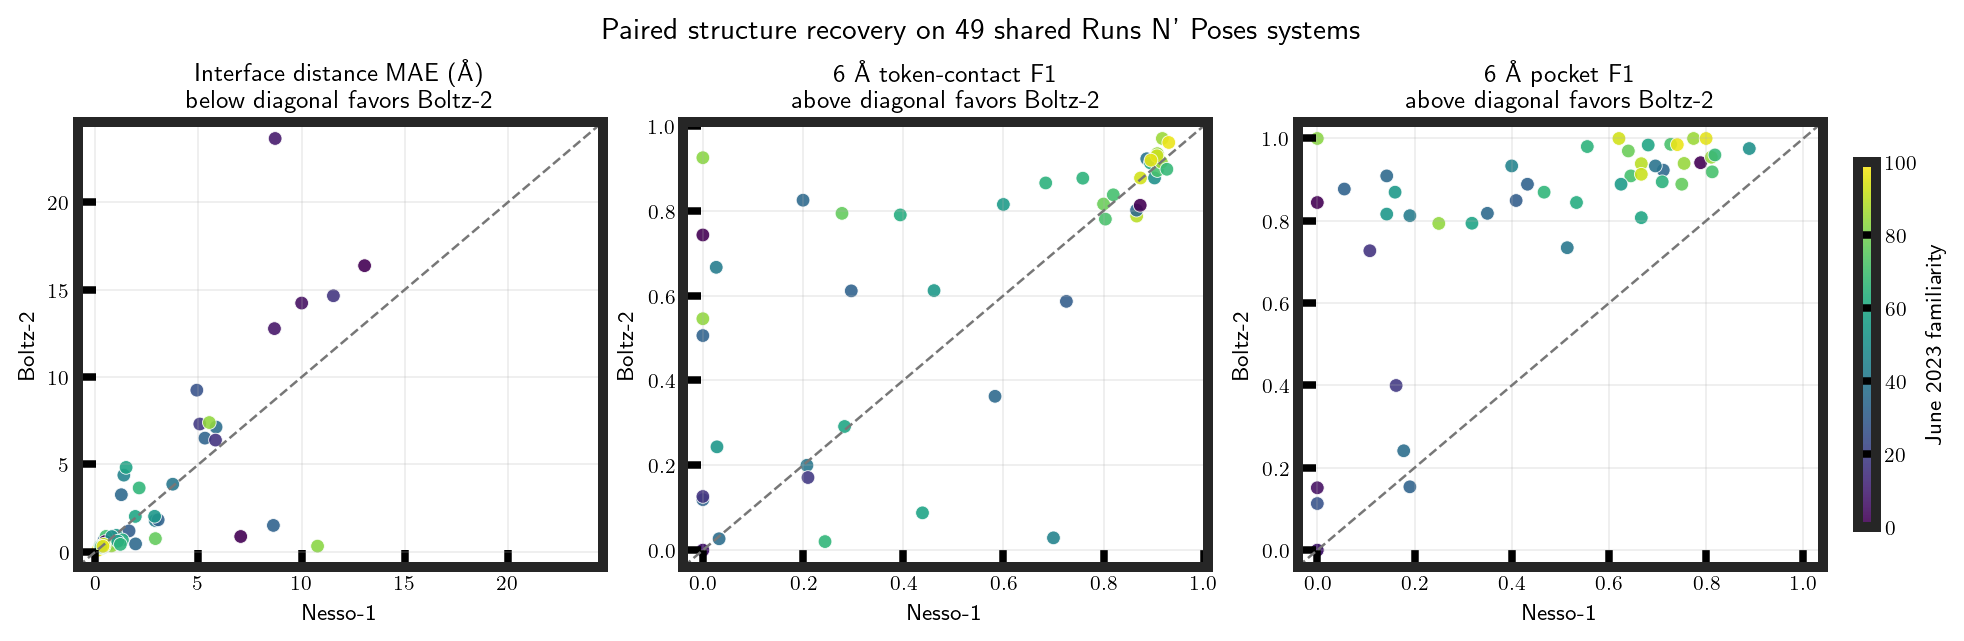

In [4]:
display(Image(filename=str(RESULT / "paired_structure_metrics.png"), width=1100))

The clearest separation is pocket recovery: Boltz-2 is better on
44 of 49 paired systems. Contact F1 also favors Boltz-2 on average. Interface
distance MAE is more mixed; its paired interval overlaps zero, so the lower
Boltz cohort median is not evidence of a consistent system-by-system win.

## 4. Accuracy versus structural familiarity

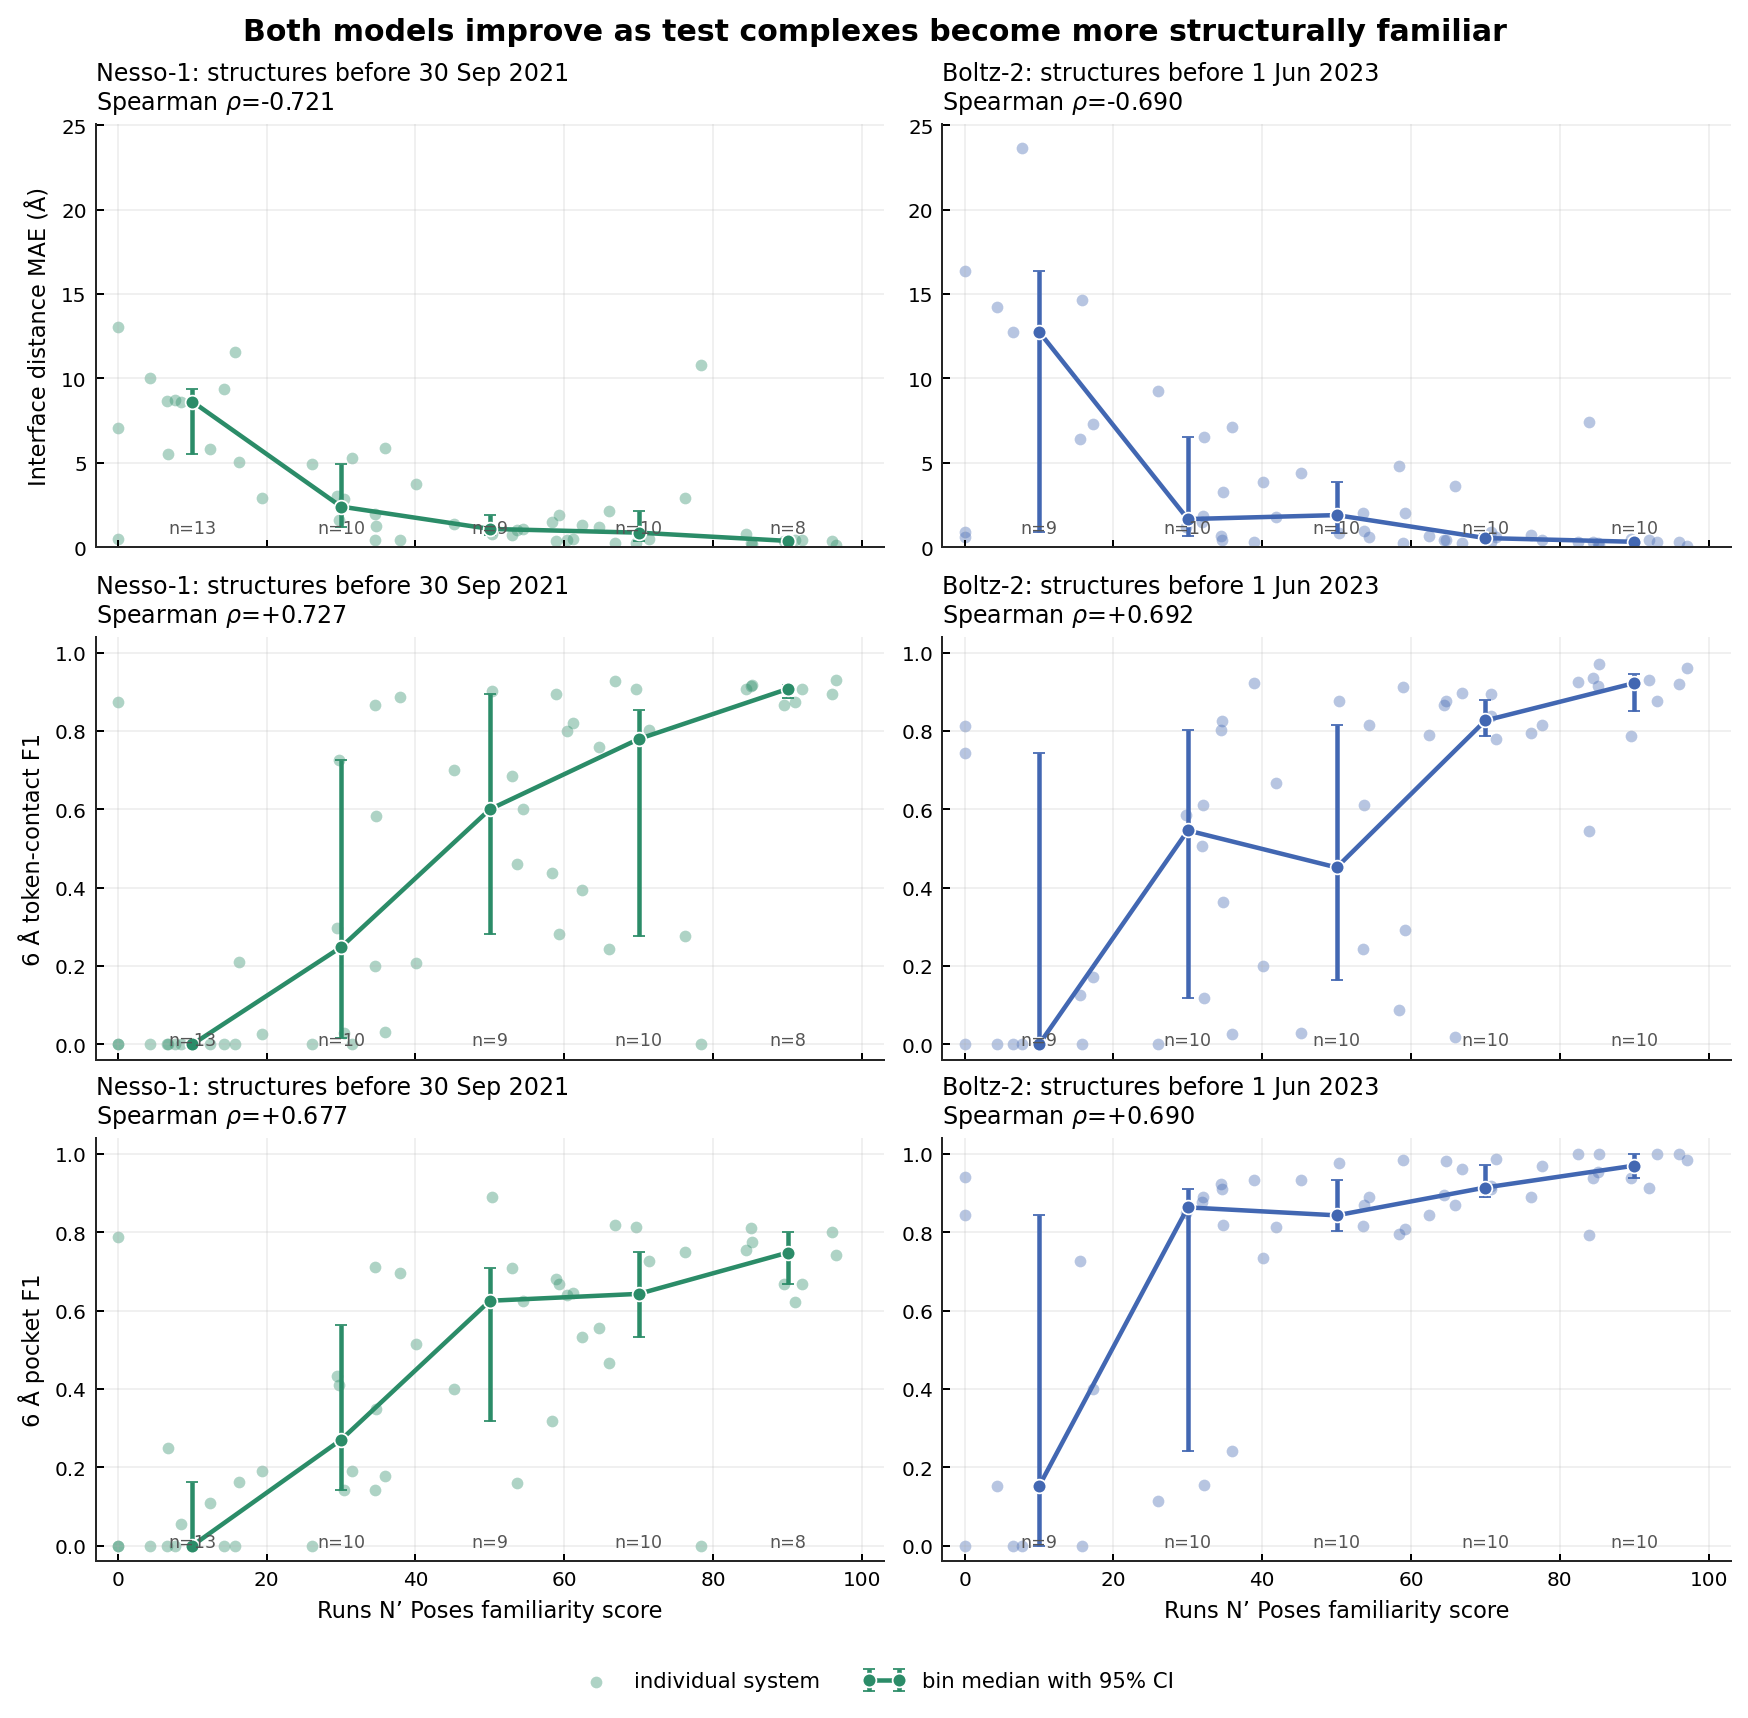

In [5]:
display(Image(filename=str(RESULT / "familiarity_vs_accuracy.png"), width=950))

In [6]:
familiarity = summary["model_specific_familiarity"]
rows = []
for model in ("nesso1", "boltz2"):
    cutoff = familiarity[f"{model}_cutoff"]
    for metric, label in labels.items():
        result = familiarity[model][metric]
        rows.append({
            "model": model,
            "cutoff": cutoff,
            "metric": label,
            "Spearman rho": result["rho"],
            "95% lower": result["lower_95"],
            "95% upper": result["upper_95"],
            "n": result["n"],
        })
display(pd.DataFrame(rows).set_index(["model", "cutoff", "metric"]).round(3))

Spearman rho  \
model  cutoff     metric                                                   
nesso1 2021-09-30 Interface distance MAE (Å; lower better)        -0.721   
                  6 Å token-contact F1 (higher better)             0.727   
                  6 Å pocket F1 (higher better)                    0.677   
boltz2 2023-06-01 Interface distance MAE (Å; lower better)        -0.690   
                  6 Å token-contact F1 (higher better)             0.692   
                  6 Å pocket F1 (higher better)                    0.690   

                                                            95% lower  \
model  cutoff     metric                                                
nesso1 2021-09-30 Interface distance MAE (Å; lower better)     -0.876   
                  6 Å token-contact F1 (higher better)          0.511   
                  6 Å pocket F1 (higher better)                 0.433   
boltz2 2023-06-01 Interface distance MAE (Å; lower better)     -0.839   
                  6 Å token-contact F1 (higher better)          0.485   
                  6 Å pocket F1 (higher better)                 0.472   

                                                            95% upper   n  
model  cutoff     metric                                                   
nesso1 2021-09-30 Interface distance MAE (Å; lower better)     -0.486  50  
                  6 Å token-contact F1 (higher better)          0.876  50  
                  6 Å pocket F1 (higher better)                 0.854  50  
boltz2 2023-06-01 Interface distance MAE (Å; lower better)     -0.475  49  
                  6 Å token-contact F1 (higher better)          0.828  49  
                  6 Å pocket F1 (higher better)                 0.831  49

For both models, familiarity has a strong monotonic association
with accuracy: distance error decreases (negative ρ), while contact and pocket
F1 increase (positive ρ). Each model uses its own historically appropriate
cutoff, so their familiarity x-values should not be overlaid as though they were
the same quantity. This association does not by itself prove memorization or
causality.

## 5. Coordinate-only questions for Boltz-2

In [7]:
pose = summary["boltz2_coordinate_metrics"]
pd.Series({
    "completed structures": pose["n"],
    "median global protein Cα RMSD (Å)": pose["protein_global_ca_rmsd_angstrom_median"],
    "median ligand RMSD after protein alignment (Å)": pose["ligand_rmsd_angstrom_median"],
    "ligand RMSD <2 Å": f"{pose['ligand_rmsd_below_2_angstrom']}/{pose['n']}",
    "ligand RMSD <5 Å": f"{pose['ligand_rmsd_below_5_angstrom']}/{pose['n']}",
})

completed structures                                    49
median global protein Cα RMSD (Å)                 0.893679
median ligand RMSD after protein alignment (Å)    3.354778
ligand RMSD <2 Å                                     22/49
ligand RMSD <5 Å                                     30/49
dtype: object

Ligand RMSD is symmetry-corrected and measured after a fixed
global protein alignment. The ligand is never fitted to itself. Nesso-1 has no
corresponding RMSD because it does not generate a coordinate model.

## 6. What we can conclude

- Both models are much more reliable on structurally familiar systems.
- Boltz-2 provides substantially better explicit pocket recovery and enables
  coordinate-level pose analysis.
- Nesso-1 is faster and remains competitive on interface-distance error.
- This does **not** test affinity accuracy, and it is only one seed/sample per
  system. A pre-registered multi-seed Boltz experiment is the natural next step.
